# Customer Segmentation for Banking

Identify behavioural customer segments using K-Means clustering and translate the resulting profiles into actionable product and engagement strategies.

## Overview

Customer behaviour varies substantially across spending, income, debt, credit usage, and demographic characteristics. 
This analysis uses unsupervised learning to identify distinct customer segments and translate those segments into 
practical banking strategies.

The workflow covers data preparation, exploratory analysis, feature scaling, cluster selection, K-Means clustering,
cluster validation, and customer profiling.

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats.mstats import winsorize
from kneed import KneeLocator

pd.set_option('display.precision', 3)

## 1. Data Preparation

In [2]:
df = pd.read_csv('bank_data.csv',index_col=0)

cluster_vars = ['c0', 'limit', 'inc0', 'w0', 'deb0', 'age']

In [3]:
df.describe()

,limit,n_cc,inc0,w0,c0,safety_score,deg,female,age,deb0,del
count,6493.000,6493.000,6493.000,6493.000,6493.000,6493.000,6493.000,6493.000,6493.000,6493.000,6493.000
mean,11.197,2.798,11.508,131.783,11.453,0.019,3.183,0.425,38.486,0.844,0.006
std,13.254,0.469,6.823,149.583,4.866,0.935,1.266,0.494,11.375,1.280,0.076
min,0.425,1.000,1.972,0.000,4.627,-3.480,1.000,0.000,21.000,0.000,0.000
25%,2.988,3.000,6.495,42.656,8.282,-0.311,2.000,0.000,28.000,0.000,0.000
50%,6.562,3.000,10.951,86.528,10.559,0.249,3.000,0.000,39.000,0.000,0.000
75%,13.906,3.000,14.208,157.969,13.079,0.615,4.000,1.000,47.000,1.554,0.000
max,155.409,4.000,72.989,926.937,31.156,1.488,5.000,1.000,64.000,9.498,1.000


In [4]:
for var in cluster_vars:
    df[var] = winsorize(df[var], limits=[0.01, 0.01])

## 2. Exploratory Analysis

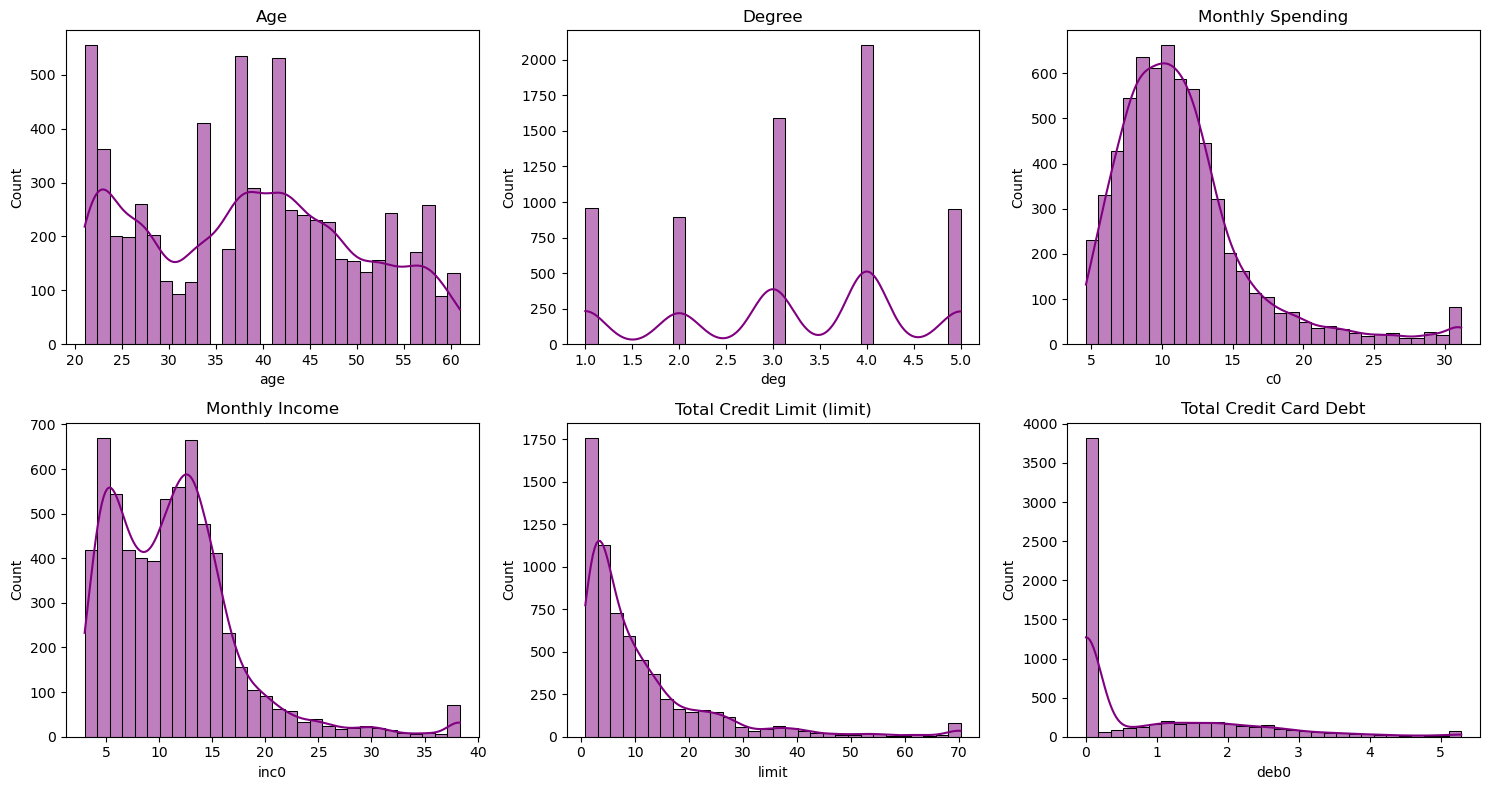

In [5]:
# Visualize distributions and relationships
plt.figure(figsize=(15, 8))


# Distribution of age (age)
plt.subplot(2, 3, 1)
sns.histplot(df['age'], bins=30, kde=True, color='purple')
plt.title('Age')


# Distribution of age (age)
plt.subplot(2, 3, 2)
sns.histplot(df['deg'], bins=30, kde=True, color='purple')
plt.title('Degree')


# Distribution of total spending (c0)
plt.subplot(2, 3, 3)
sns.histplot(df['c0'], bins=30, kde=True, color='purple')
plt.title('Monthly Spending')


# Distribution of total income (income)
plt.subplot(2, 3, 4)
sns.histplot(df['inc0'], bins=30, kde=True, color='purple')
plt.title('Monthly Income')


# Distribution of total credit limit (limit)
plt.subplot(2, 3, 5)
sns.histplot(df['limit'], bins=30, kde=True, color='purple')
plt.title('Total Credit Limit (limit)')


# Distribution of age (age)
plt.subplot(2, 3, 6)
sns.histplot(df['deb0'], bins=30, kde=True, color='purple')
plt.title('Total Credit Card Debt')

plt.tight_layout()
plt.show()

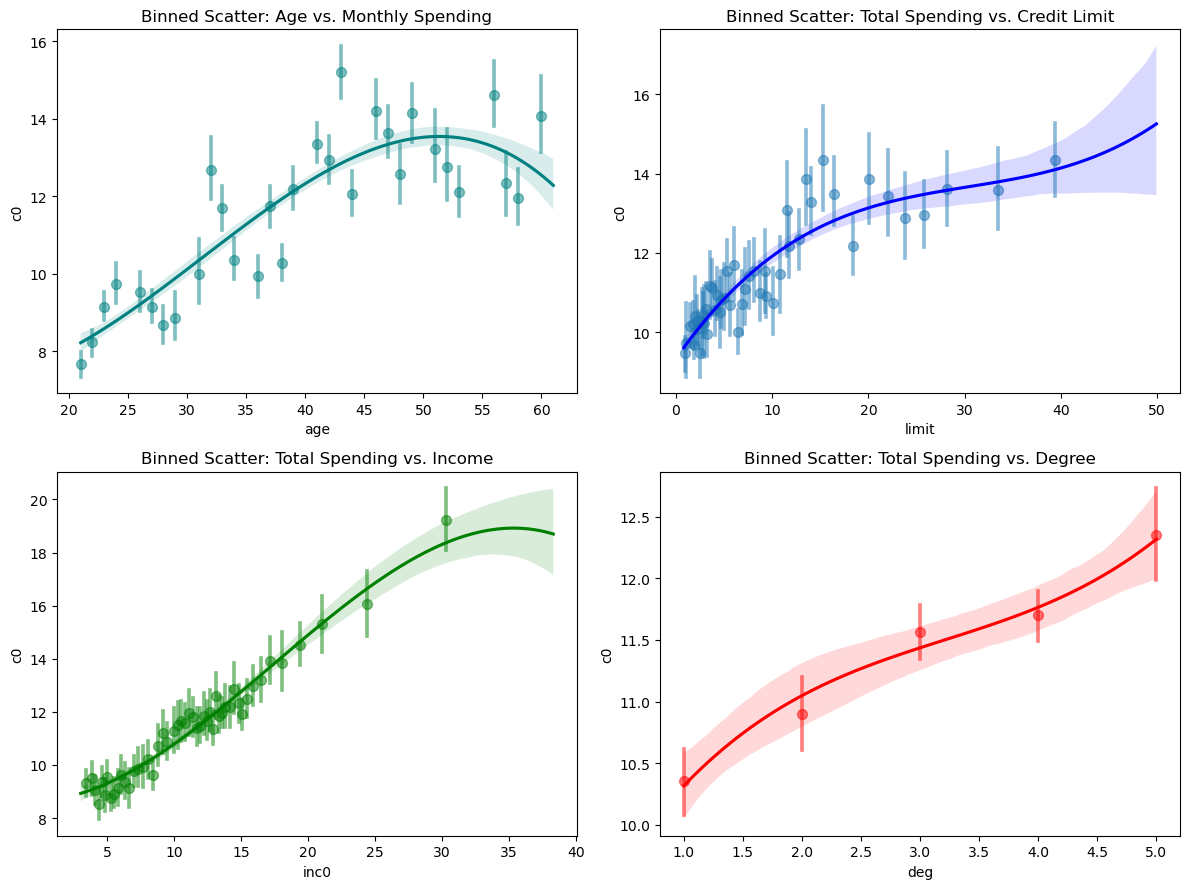

In [6]:
plt.figure(figsize=(12, 9))

# Binned Scatter Plot: age vs. Monthly Spending
plt.subplot(2, 2, 1)
sns.regplot(data=df, x='age', y='c0', x_bins=50, scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'teal'}, order=3)
plt.title('Binned Scatter: Age vs. Monthly Spending')


# Binned Scatter Plot: Spending vs. Credit Limit
plt.subplot(2, 2, 2)
sns.regplot(data=df.loc[df.limit < 50,:], x='limit', y='c0', x_bins=50, scatter_kws={'alpha':0.5}, line_kws={'color':'blue'}, order=3)
plt.title('Binned Scatter: Total Spending vs. Credit Limit')

# Binned Scatter Plot: Spending vs. Income
plt.subplot(2, 2, 3)
sns.regplot(data=df.loc[df.inc0 < 40,:], x='inc0', y='c0', x_bins=50, scatter_kws={'alpha':0.5, 'color':'green'}, line_kws={'color':'green'}, order=3)
plt.title('Binned Scatter: Total Spending vs. Income')

# Binned Scatter Plot: Spending vs. Degree
plt.subplot(2, 2, 4)
sns.regplot(data=df, x='deg', y='c0', x_bins=50, scatter_kws={'alpha':0.5, 'color':'red'}, line_kws={'color':'red'}, order=3)
plt.title('Binned Scatter: Total Spending vs. Degree')

plt.tight_layout()
plt.show()

## 3. Feature Scaling

In [7]:
# Standardize the variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_vars])
# Determine optimal number of clusters using Elbow method
wcss = []
for i in range(1, 21):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

## 4. Selecting the Number of Clusters

Optimal number of clusters suggested: 6


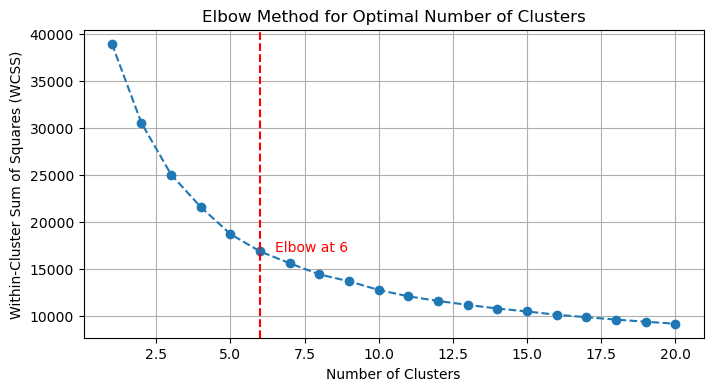

In [8]:
# Detect the elbow point automatically
# kl finds the point of maximum curvature
kl = KneeLocator(range(1, 21), wcss, curve='convex', direction='decreasing')

optimal_clusters = kl.elbow
print(f'Optimal number of clusters suggested: {optimal_clusters}')

# Plot Elbow curve with optimal cluster marker
plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.axvline(x=optimal_clusters, color='r', linestyle='--')
plt.text(optimal_clusters + 0.5, wcss[optimal_clusters - 1], f'Elbow at {optimal_clusters}', color='red')
plt.grid(True)
plt.show()

### Cluster Validation

Silhouette scores were evaluated across candidate cluster counts.
The score measures how well each observation fits within its assigned
cluster relative to neighbouring clusters.

The highest score occurs at 7 clusters (0.256), which provides the
strongest separation among the tested specifications.

In [9]:
silhouette_scores = []
range_n_clusters = range(2, 11)

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)


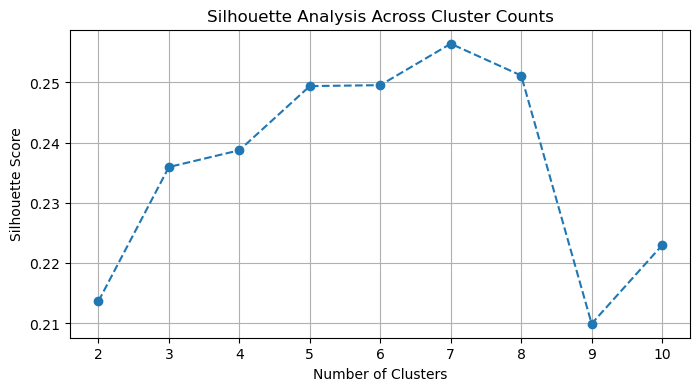

In [10]:
# Plot Silhouette Scores
plt.figure(figsize=(8, 4))
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis Across Cluster Counts')
plt.grid(True)
plt.show()

## 5. Customer Segmentation

In [11]:
# Fit the final K-Means model using the selected number of clusters
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [12]:
# Calculate silhouette score
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f'Silhouette Score: {silhouette_avg:.3f}')

Silhouette Score: 0.256


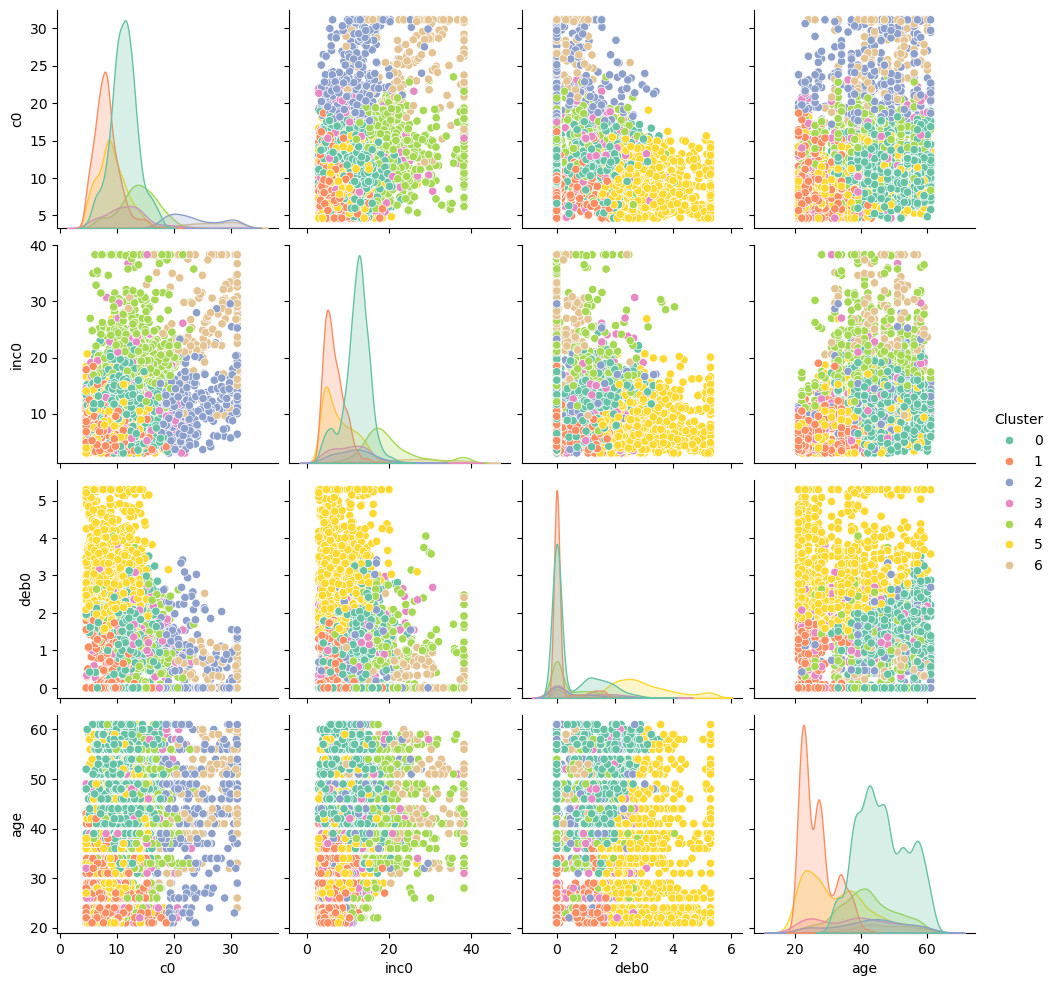

In [13]:
# Visualize resulting clusters
sns.pairplot(df, vars=['c0', 'inc0', 'deb0', 'age'], hue='Cluster', palette='Set2')
plt.show()

In [ ]:
# Cluster summary
cluster_summary = (
    df[['c0', 'limit', 'inc0', 'w0', 'deb0', 'age', 'Cluster']]
    .groupby('Cluster')
    .mean()
)

print(cluster_summary)

             c0   limit    inc0       w0   deb0     age
Cluster                                                
0        11.263   7.795  12.132   91.376  0.482  46.503
1         8.241   6.689   6.680   92.114  0.149  26.684
2        23.737  12.497  11.837  160.155  0.555  42.697
3        11.582  46.485  11.093  135.544  0.756  38.283
4        13.845  12.810  20.143  285.456  0.471  41.561
5         9.069   7.055   8.049   66.719  3.018  32.548
6        25.872  27.941  27.003  800.895  0.293  46.340


## 6. Segment Profiling

### Characteristics

| Cluster | Label                    | Characteristics                                                              | Recommended Strategy                          |
|---------|--------------------------|------------------------------------------------------------------------------|-----------------------------------------------|
| **0**   | **Older, Moderate Spenders**  | Older (47 yrs), moderate spending, moderate income/wealth, low debt.          | Retirement planning, stable credit offers.    |
| **1**   | **Young Low-Income Users**   | Youngest (27 yrs), lowest income & wealth, lowest spending, minimal debt.       | Starter products, financial literacy.         |
| **2**   | **Mature High-Spenders**     | Older (43 yrs), high spending, moderate-high wealth, low debt, moderate credit limit. | Premium cards, targeted loyalty programs.     |
| **3**   | **High Credit Limit Users**  | Moderate age (38 yrs), highest credit limits, moderate wealth/income, moderate spending. | Credit expansion, premium credit products.    |
| **4**   | **Affluent Middle-Aged Users**| Middle-aged (42 yrs), high income & wealth, high spending, low debt.          | Wealth management, personalized banking.      |
| **5**   | **Young High-Debt Group**    | Younger (33 yrs), moderate spending, low income, highest debt.                 | Debt management, financial counseling.        |
| **6**   | **High-Value Affluent Users**     | Oldest (46 yrs), highest income/wealth, highest spending, very low debt.       | Premium banking and investment-oriented products.|

## 7. Business Recommendations

The segmentation suggests three broad opportunities for differentiated customer engagement.

**Premium engagement - Clusters 2, 4, and 6**

These segments combine relatively strong financial profiles with higher spending intensity.
They are natural candidates for premium products, personalised offers, and loyalty programmes.

**Financial support - Clusters 1 and 5**

These segments display relatively lower financial capacity and spending.
Product design should emphasise accessible products, financial education, and appropriate credit management
rather than aggressive cross-selling.

**Core customer development - Clusters 0 and 3**

These segments show relatively stable financial profiles and provide opportunities for targeted
cross-selling, product expansion, and gradual credit development.

## Key Takeaway

The analysis identifies seven customer segments with distinct combinations
of spending, income, credit exposure, debt, and age. While the silhouette
score indicates moderate rather than strong separation, the segmentation
provides a useful framework for differentiating customer engagement and
product strategies.